<a href="https://colab.research.google.com/github/CarlitosDamm/Tecmi/blob/main/Actividad_4_Gestion_de_Proyectos_de_IA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

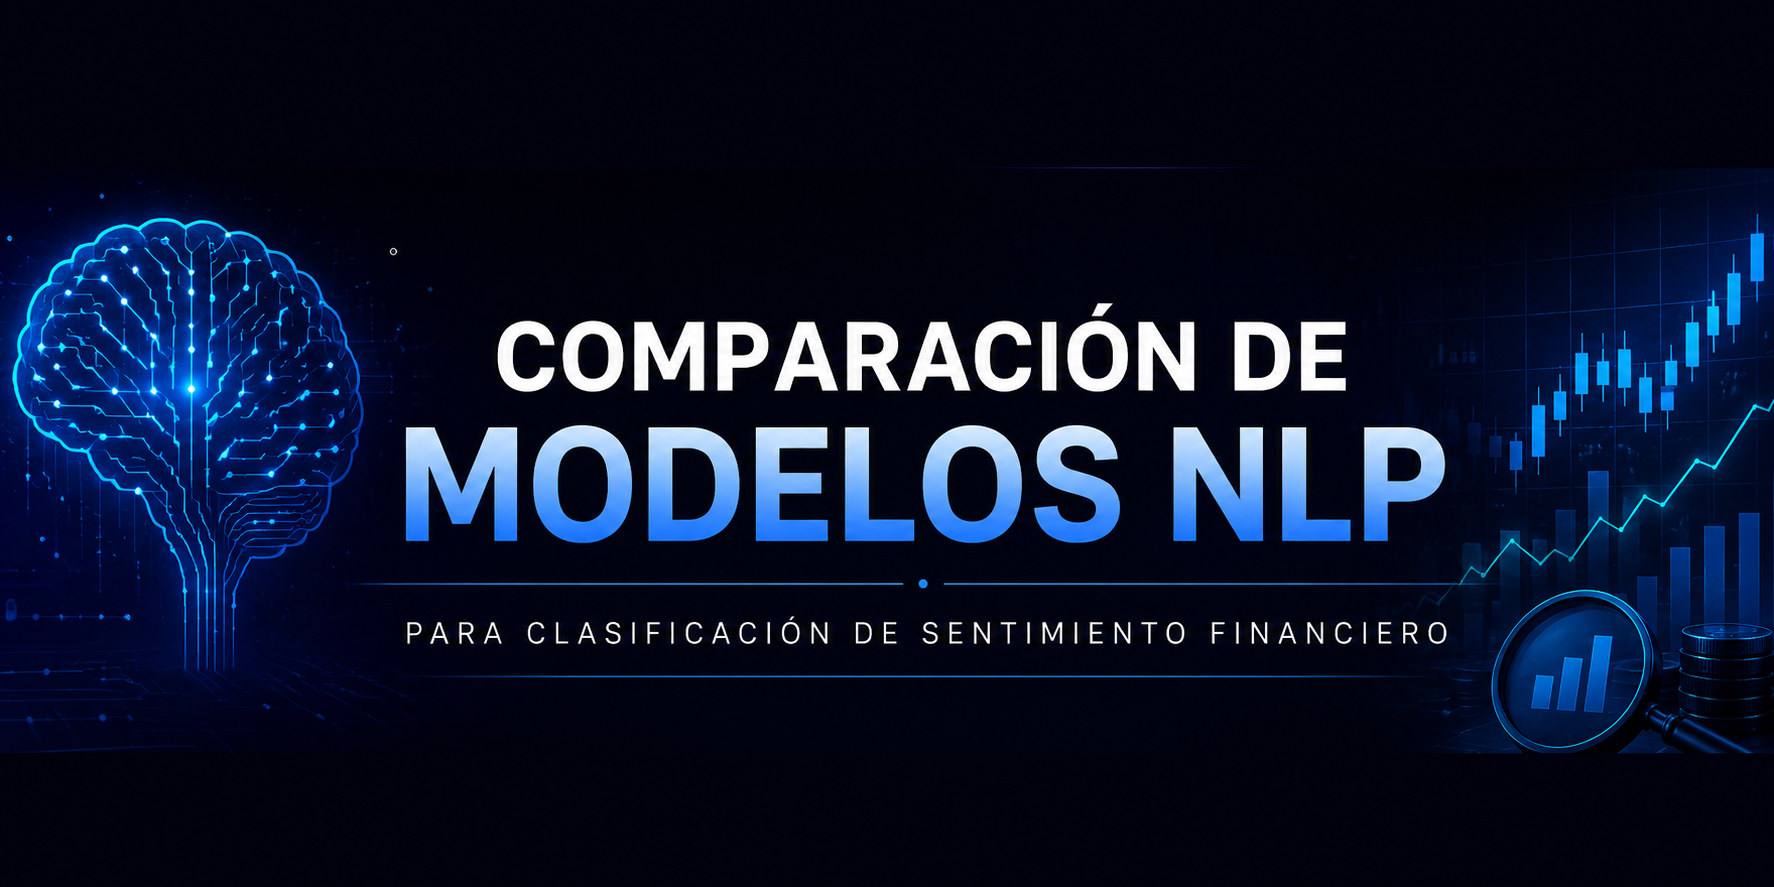

# Comparación de modelos NLP para análisis de sentimiento financiero

Este notebook comparara el desempeño de tres modelos de procesamiento de lenguaje natural para la tarea de clasificación de sentimiento financiero utilizando un mismo conjunto de datos y métricas estandarizadas de evaluación.

Se analizarán indicadores de desempeño predictivo (Accuracy, Precision, Recall y F1-score) así como métricas de eficiencia computacional (latencia promedio y tiempo total de inferencia).

La tarea consiste en clasificar cada texto como:

- Negativo
- Neutral
- Positivo

## Parte 1 - Configuracion

### Verificación de GPU

Si no se detecta, se debera de cambiar el entorno a GPU en las configuraciones

In [ ]:
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

print("Dispositivo disponible:", device)

if device == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("No se detectó GPU. Activa GPU en Entorno de ejecución > Cambiar tipo de entorno de ejecución.")

### Instalacion de Dependencias

In [ ]:
!pip install -q transformers datasets evaluate accelerate scikit-learn pandas numpy tqdm huggingface_hub

In [ ]:
!pip install -q sentencepiece

### Importar Librerias Principales

In [ ]:
import time
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report
from huggingface_hub import notebook_login

### Caso de Uso

El análisis de sentimiento financiero permite identificar la percepción positiva, negativa o neutral presente en noticias, publicaciones de redes sociales y comentarios relacionados con mercados financieros.

Esta capacidad puede ser utilizada para monitoreo de reputación, apoyo a decisiones de inversión y análisis de tendencias de mercado.

En este proyecto se usaran tres modelos preentrenados de Hugging Face para determinar cuál ofrece el mejor equilibrio entre precisión y eficiencia computacional. Se creo un usuario y un token para poder acceder a los mismos.

### Autenticacion en Hugging Face

In [ ]:
from google.colab import userdata

HF_TOKEN = userdata.get("Token")

print("Token cargado correctamente.")

In [ ]:
from huggingface_hub import login

login(token=HF_TOKEN)

### Carga del Dataset

In [ ]:
dataset = load_dataset("zeroshot/twitter-financial-news-sentiment")

dataset

### Exploracion de Estructura

In [ ]:
print(dataset)

print("\nColumnas disponibles:")
print(dataset["train"].column_names)

print("\nEjemplo de registro:")
print(dataset["train"][0])

### Distribucion de Etiquetas

In [ ]:
train_df = pd.DataFrame(dataset["train"])
valid_df = pd.DataFrame(dataset["validation"])

print("Distribución entrenamiento:")
display(train_df["label"].value_counts().sort_index())

print("Distribución validación:")
display(valid_df["label"].value_counts().sort_index())

Interpretación de etiquetas del dataset:

- 0 = Negativa
- 1 = Positiva
- 2 = Neutral

## Parte 2 - Preparacion de la Evaluacion

### Variables de Evaluacion

In [ ]:
eval_df = valid_df.copy()

texts = eval_df["text"].tolist()
y_true = eval_df["label"].tolist()

print("Total de registros para evaluación:", len(texts))
print("Primer texto:", texts[0])
print("Primera etiqueta real:", y_true[0])

### Mapeo de Etiquetas

Cada modelo tiene un set de etiquetas el cual no esta sicronizado, por lo que se tuvo que mapear cada uno para alinearlos y poder ser comparados al final

In [ ]:
MODEL_LABEL_MAPS = {
    "ProsusAI/finbert": {
        "positive": 1,
        "negative": 0,
        "neutral": 2
    },

    "mrm8488/distilroberta-finetuned-financial-news-sentiment-analysis": {
        "negative": 0,
        "neutral": 2,
        "positive": 1
    },

    "cardiffnlp/twitter-roberta-base-sentiment": {
        "LABEL_0": 0,  # negativa
        "LABEL_1": 2,  # neutral
        "LABEL_2": 1   # positiva
    }
}

### Funcion para Evaluar los Modelos

In [ ]:
def evaluate_model(model_name, texts, y_true, batch_size=32, max_length=128):
    print(f"\nEvaluando modelo: {model_name}")

    tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=False)
    model = AutoModelForSequenceClassification.from_pretrained(model_name)
    model.to(device)
    model.eval()

    label_map = MODEL_LABEL_MAPS[model_name]
    predictions = []

    start_time = time.time()

    with torch.no_grad():
        for i in tqdm(range(0, len(texts), batch_size)):
            batch_texts = texts[i:i + batch_size]

            inputs = tokenizer(
                batch_texts,
                padding=True,
                truncation=True,
                max_length=max_length,
                return_tensors="pt"
            )

            inputs = {k: v.to(device) for k, v in inputs.items()}

            outputs = model(**inputs)
            logits = outputs.logits

            pred_ids = torch.argmax(logits, dim=1).cpu().numpy()
            id2label = model.config.id2label

            for pred_id in pred_ids:
                raw_label = id2label[int(pred_id)]
                predictions.append(label_map[raw_label])

    end_time = time.time()

    total_time = end_time - start_time
    avg_latency = total_time / len(texts)

    accuracy = accuracy_score(y_true, predictions)

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true,
        predictions,
        average="weighted",
        zero_division=0
    )

    results = {
        "model": model_name,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "total_time_sec": total_time,
        "avg_latency_sec": avg_latency
    }

    print("\nResultados:")
    print(results)

    print("\nReporte por clase:")
    print(classification_report(
        y_true,
        predictions,
        target_names=["Bearish/Negative", "Bullish/Positive", "Neutral"],
        zero_division=0
    ))

    return results, predictions

## Parte 3 - Modelos

### Modelos a Evaluar

Se eligieron estos 3 modelos ya que tienen aplicaciones un poco diferentes y pueden ayudar al analisis global, finbert es un modelo hecho especificamente para analisis financiero, roberta es un modelo generico para analisis de tweets en general y roberta-financiera es un sub modelo de roberta el cual fue reentrenado con temas financieros.

In [ ]:
models_to_evaluate = [
    "ProsusAI/finbert",
    "mrm8488/distilroberta-finetuned-financial-news-sentiment-analysis",
    "cardiffnlp/twitter-roberta-base-sentiment"
]

### Comparacion de Modelos

In [ ]:
model_specs = pd.DataFrame({
    "model":[
        "ProsusAI/finbert",
        "mrm8488/distilroberta-financial-news",
        "cardiffnlp/twitter-roberta"
    ],
    "architecture":[
        "BERT",
        "DistilRoBERTa",
        "RoBERTa"
    ],
    "params_millions":[
        110,
        82,
        125
    ],
    "license":[
        "Apache 2.0",
        "MIT",
        "MIT"
    ]
})

display(model_specs)

### Evaluacion de los Modelos

In [ ]:
all_results = []
all_predictions = {}

for model_name in models_to_evaluate:
    results, predictions = evaluate_model(
        model_name=model_name,
        texts=texts,
        y_true=y_true,
        batch_size=32,
        max_length=128
    )

    all_results.append(results)
    all_predictions[model_name] = predictions

Resultados

In [ ]:
results_df = pd.DataFrame(all_results)

results_df = results_df.sort_values(
    by=["f1_score", "avg_latency_sec"],
    ascending=[False, True]
)

display(results_df)

In [ ]:
plot_df = results_df.copy()

plot_df["model_short"] = plot_df["model"].replace({
    "ProsusAI/finbert": "FinBERT",
    "mrm8488/distilroberta-finetuned-financial-news-sentiment-analysis": "RoBERTa-Financiera",
    "cardiffnlp/twitter-roberta-base-sentiment": "RoBERTa"
})

In [ ]:
plt.figure(figsize=(8,4))

plt.bar(
    plot_df["model_short"],
    plot_df["accuracy"]
)

plt.title("Accuracy por Modelo")
plt.ylabel("Accuracy")
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(8,4))

plt.bar(
    plot_df["model_short"],
    plot_df["f1_score"]
)

plt.title("F1 Score por Modelo")
plt.ylabel("F1 Score")
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(8,4))

plt.bar(
    plot_df["model_short"],
    plot_df["avg_latency_sec"]
)

plt.title("Latencia Promedio por Modelo")
plt.ylabel("Segundos")
plt.tight_layout()
plt.show()

### Tabla Comparativa

In [ ]:
results_display = results_df.copy()

results_display["model"] = results_display["model"].replace({
    "ProsusAI/finbert": "FinBERT",
    "mrm8488/distilroberta-finetuned-financial-news-sentiment-analysis": "RoBERTa-Financiera",
    "cardiffnlp/twitter-roberta-base-sentiment": "RoBERTa"
})

results_display.columns = [
    "Modelo",
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "Tiempo Total (s)",
    "Latencia Promedio (s)"
]

display(results_display)

### Guardar Resultados

In [ ]:
results_display.to_csv(
    "model_comparison_results.csv",
    index=False
)

print("Resultados guardados en model_comparison_results.csv")

In [ ]:
prediction_df = pd.DataFrame({
    "text": texts,
    "actual": y_true,
    "finbert": all_predictions["ProsusAI/finbert"],
    "distilroberta": all_predictions["mrm8488/distilroberta-finetuned-financial-news-sentiment-analysis"],
    "twitter_roberta": all_predictions["cardiffnlp/twitter-roberta-base-sentiment"]
})

prediction_df.to_csv(
    "all_predictions.csv",
    index=False
)

## Parte 4 - Conclusiones Parciales

A partir de los resultados obtenidos, se observan diferencias claras entre los tres modelos evaluados en términos de desempeño predictivo y latencia promedio.

El modelo RoBERTa-Financiera obtuvo el mejor F1-score y la menor latencia promedio dentro de esta evaluación, mientras que FinBERT presentó un desempeño competitivo pero con mayor tiempo de inferencia. Por otro lado, RoBERTa general obtuvo resultados menores, lo cual puede explicarse porque no está especializado en lenguaje financiero.

Estos resultados sugieren que los modelos ajustados al dominio financiero ofrecen ventajas para este caso de uso. Sin embargo, la recomendación final debe considerar también factores como licencia, tamaño del modelo, recursos computacionales, riesgos y contexto de implementación.